In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [28]:
def locally_weighted_regression(X, y, tau, x_query):
    m = X.shape[0]

    # Memory-safe Gaussian weights (no m x m diagonal matrix)
    diff = X - x_query
    sq_dist = np.sum(diff * diff, axis=1)
    w = np.exp(-sq_dist / (2 * tau**2))

    # Weighted normal equation using vector weights
    XTWX = X.T @ (X * w[:, None])
    XTWy = X.T @ (w * y)

    # Small ridge term improves numerical stability for near-singular cases
    ridge = 1e-8 * np.eye(X.shape[1])
    theta = np.linalg.pinv(XTWX + ridge) @ XTWy

    return x_query @ theta


def lwr_predict(X_train, y_train, X_test, tau):
    predictions = np.array([
        locally_weighted_regression(X_train, y_train, tau, x)
        for x in X_test
    ])
    return predictions

In [ ]:
# Load Fish Market dataset
fish_path = '../data/Fish.csv'
fish_df = pd.read_csv(fish_path)

# Use one feature for 1D LWR demonstration
feature_col = 'Length3'
target_col = 'Weight'

fish_df = fish_df[[feature_col, target_col]].dropna()
fish_df = fish_df[fish_df[target_col] > 0].copy()

X = fish_df[[feature_col]].values
y = fish_df[target_col].values

# Normalize feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add intercept term for LWR
X_design = np.hstack((np.ones((X_scaled.shape[0], 1)), X_scaled))

print('Fish Dataset Shape:', X_design.shape)
print('Target (Weight) Range:', y.min(), 'to', y.max())
print('\nFirst 5 rows:')
print(fish_df.head())

Synthetic Dataset Shape: (500, 2)
Target Values Range: -1.5688698275820323 to 1.689185268876818

First 5 samples:
    Feature    Target
0 -9.898768  0.558967
1 -9.889558  1.011077
2 -9.860957  0.707607
3 -9.816059  0.208302
4 -9.783247  0.081317


In [ ]:
# Apply LWR with different tau values on Fish Market data
tau_values = [0.1, 0.5, 1.0, 2.0]
predictions_dict = {}

for tau in tau_values:
    y_pred = lwr_predict(X_design, y, X_design, tau)
    predictions_dict[tau] = y_pred
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    print(f'Tau = {tau}: MSE = {mse:.4f}, R² = {r2:.4f}')

# Use a default tau for visualization (grid search below finds best one)
optimal_tau = 0.5
y_pred_optimal = predictions_dict[optimal_tau]

Tau = 0.1: MSE = 0.0993, R² = 0.8166
Tau = 0.5: MSE = 0.4704, R² = 0.1313
Tau = 1.0: MSE = 0.4982, R² = 0.0801
Tau = 2.0: MSE = 0.5028, R² = 0.0716


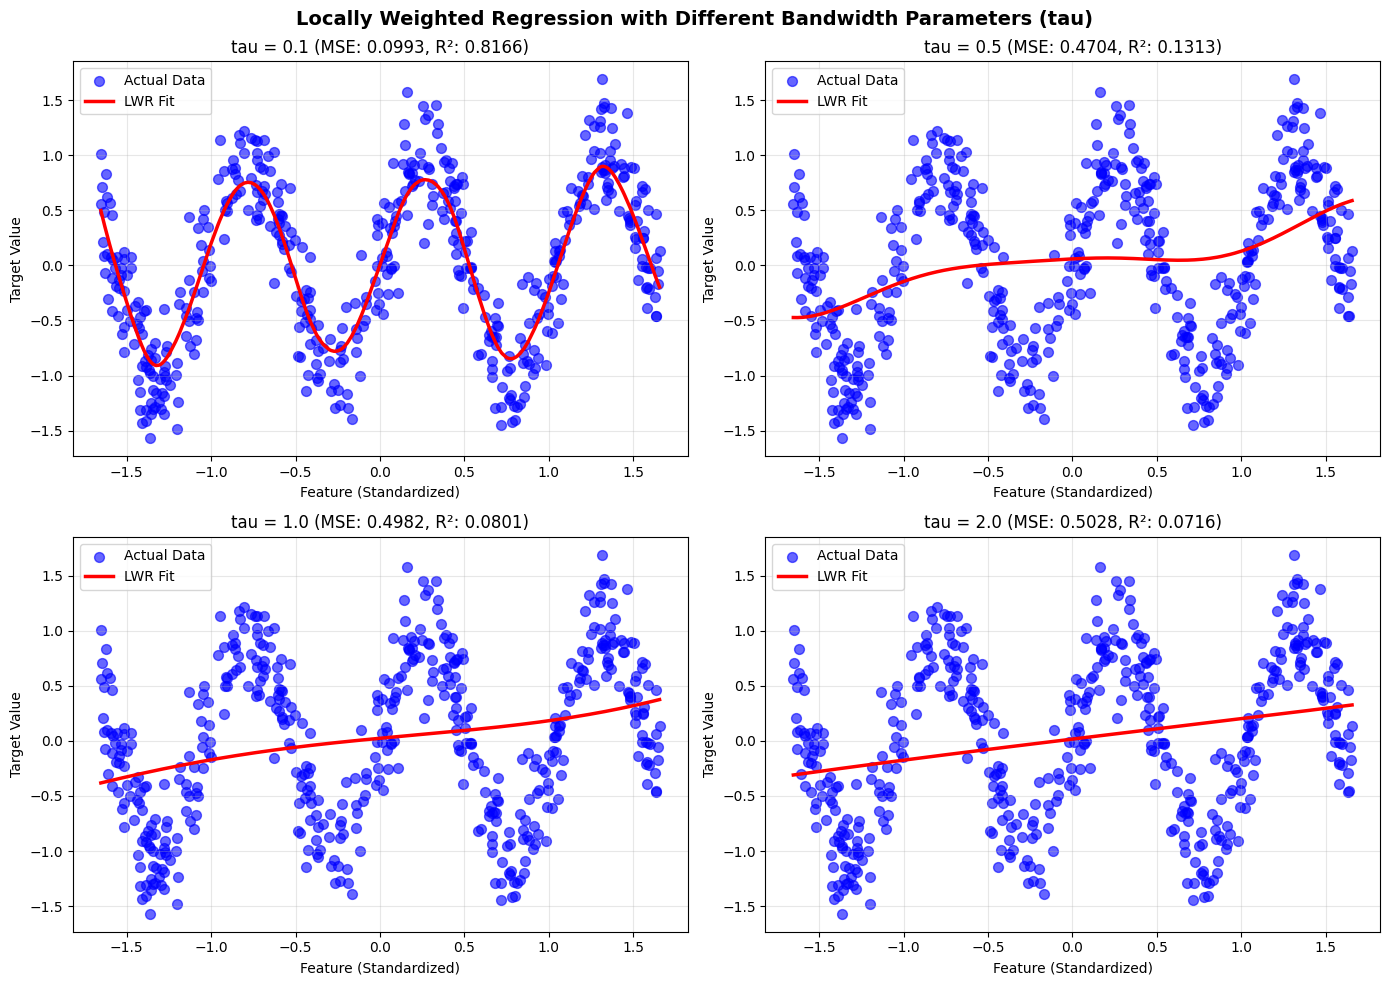

✓ Visualization saved as 'lwr_synthetic_tau_comparison.png'


In [ ]:
# Visualization: Effect of different tau values on Fish Market data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Locally Weighted Regression on Fish Market (Weight vs Length3)',
             fontsize=14, fontweight='bold')

for idx, tau in enumerate(tau_values):
    ax = axes[idx // 2, idx % 2]

    # Sort for smooth plotting
    sorted_idx = X_scaled[:, 0].argsort()

    ax.scatter(X_scaled[sorted_idx, 0], y[sorted_idx],
               color='blue', alpha=0.6, label='Actual Data', s=45)
    ax.plot(X_scaled[sorted_idx, 0], predictions_dict[tau][sorted_idx],
            color='red', linewidth=2.5, label='LWR Fit')

    mse = mean_squared_error(y, predictions_dict[tau])
    r2 = r2_score(y, predictions_dict[tau])

    ax.set_title(f'tau = {tau} (MSE: {mse:.4f}, R²: {r2:.4f})')
    ax.set_xlabel('Length3 (Standardized)')
    ax.set_ylabel('Weight')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lwr_fish_tau_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'lwr_fish_tau_comparison.png'")

Searching for optimal tau parameter...

Optimal tau found: 0.1000
Best MSE: 0.0993
Best R²: 0.8166


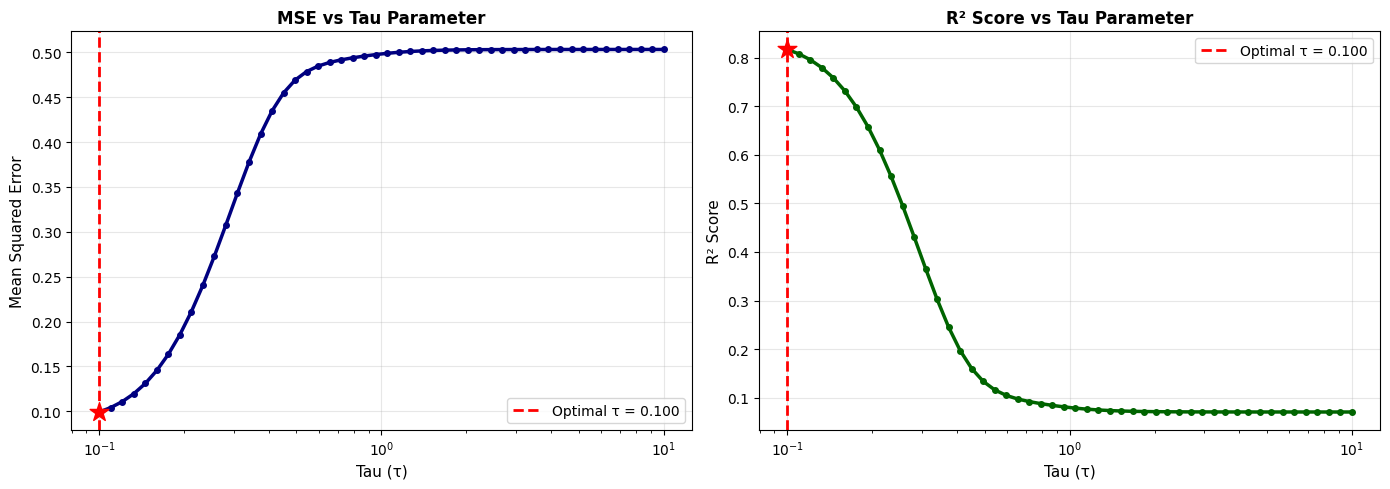

✓ Tau optimization visualization saved as 'lwr_tau_optimization.png'


In [ ]:
# Grid search for optimal tau on Fish Market data
tau_range = np.logspace(-1, 1, 50)  # From 0.1 to 10
mse_scores = []
r2_scores = []

print('Searching for optimal tau parameter...')
for tau in tau_range:
    try:
        y_pred_tau = lwr_predict(X_design, y, X_design, tau)
        mse = mean_squared_error(y, y_pred_tau)
        r2 = r2_score(y, y_pred_tau)
        mse_scores.append(mse)
        r2_scores.append(r2)
    except Exception:
        mse_scores.append(np.nan)
        r2_scores.append(np.nan)

mse_scores = np.array(mse_scores)
r2_scores = np.array(r2_scores)

optimal_tau_idx = np.nanargmin(mse_scores)
optimal_tau_found = tau_range[optimal_tau_idx]
optimal_mse = mse_scores[optimal_tau_idx]
optimal_r2 = r2_scores[optimal_tau_idx]

print(f'\nOptimal tau found: {optimal_tau_found:.4f}')
print(f'Best MSE: {optimal_mse:.4f}')
print(f'Best R²: {optimal_r2:.4f}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE curve
axes[0].plot(tau_range, mse_scores, linewidth=2.5, color='navy', marker='o', markersize=4)
axes[0].axvline(x=optimal_tau_found, color='red', linestyle='--', linewidth=2, label=f'Optimal τ = {optimal_tau_found:.3f}')
axes[0].scatter(optimal_tau_found, optimal_mse, color='red', s=200, zorder=5, marker='*')
axes[0].set_xlabel('Tau (τ)', fontsize=11)
axes[0].set_ylabel('Mean Squared Error', fontsize=11)
axes[0].set_title('MSE vs Tau Parameter (Fish Market)', fontweight='bold', fontsize=12)
axes[0].set_xscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# R² curve
axes[1].plot(tau_range, r2_scores, linewidth=2.5, color='darkgreen', marker='o', markersize=4)
axes[1].axvline(x=optimal_tau_found, color='red', linestyle='--', linewidth=2, label=f'Optimal τ = {optimal_tau_found:.3f}')
axes[1].scatter(optimal_tau_found, optimal_r2, color='red', s=200, zorder=5, marker='*')
axes[1].set_xlabel('Tau (τ)', fontsize=11)
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_title('R² Score vs Tau Parameter (Fish Market)', fontweight='bold', fontsize=12)
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('lwr_fish_tau_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Tau optimization visualization saved as 'lwr_fish_tau_optimization.png'")

## Prediction and UI

Use the next cells to:
1. Predict `Weight` for any custom fish `Length3` value
2. Interactively tune `Length3` and `tau` and visualize the predicted point on the fitted LWR curve

In [ ]:
# Manual prediction helper for Fish Market dataset

def predict_weight_for_length3(length3_raw, tau=None):
    """Predict fish Weight for a raw Length3 value."""
    if tau is None:
        tau = float(optimal_tau_found) if 'optimal_tau_found' in globals() else float(optimal_tau)

    x_scaled = scaler.transform(np.array([[length3_raw]], dtype=float))
    x_query = np.hstack((np.ones((1, 1)), x_scaled))[0]
    y_hat = locally_weighted_regression(X_design, y, tau, x_query)
    return float(y_hat), float(tau)

# Example prediction
length3_example = float(np.median(X))
weight_example, tau_used = predict_weight_for_length3(length3_example)
print(f'Prediction for Length3 = {length3_example:.2f} with tau = {tau_used:.4f}: Weight = {weight_example:.4f}')

Prediction for x = 2.50 with tau = 0.1000: y = 0.5019


In [ ]:
# Interactive UI (slider-based) for prediction and visualization
try:
    import ipywidgets as widgets
    from IPython.display import display

    x_min, x_max = float(X.min()), float(X.max())
    tau_default = float(optimal_tau_found) if 'optimal_tau_found' in globals() else float(optimal_tau)

    x_slider = widgets.FloatSlider(
        value=float(np.median(X)),
        min=x_min,
        max=x_max,
        step=0.1,
        description='Length3:',
        continuous_update=False,
        readout_format='.2f'
    )

    tau_slider = widgets.FloatSlider(
        value=tau_default,
        min=0.1,
        max=2.5,
        step=0.05,
        description='tau:',
        continuous_update=False,
        readout_format='.2f'
    )

    output = widgets.Output()

    def update_plot(change=None):
        with output:
            output.clear_output(wait=True)

            x_val = float(x_slider.value)
            tau_val = float(tau_slider.value)

            # Predict all points for curve and one custom point for highlight
            y_curve = lwr_predict(X_design, y, X_design, tau_val)
            y_hat, _ = predict_weight_for_length3(x_val, tau_val)

            x_scaled_custom = scaler.transform(np.array([[x_val]], dtype=float))[0, 0]
            sorted_idx = X_scaled[:, 0].argsort()

            plt.figure(figsize=(9, 5))
            plt.scatter(X_scaled[:, 0], y, color='steelblue', alpha=0.45, s=25, label='Fish Data')
            plt.plot(X_scaled[sorted_idx, 0], y_curve[sorted_idx], color='crimson', linewidth=2.3, label='LWR curve')
            plt.scatter([x_scaled_custom], [y_hat], color='black', s=90, marker='X', label=f'Prediction ({x_val:.2f}, {y_hat:.2f})')

            plt.title(f'LWR Interactive Prediction (tau = {tau_val:.2f})')
            plt.xlabel('Length3 (Standardized)')
            plt.ylabel('Weight')
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()

            print(f'Predicted Weight for Length3={x_val:.2f}: {y_hat:.4f}')

    x_slider.observe(update_plot, names='value')
    tau_slider.observe(update_plot, names='value')

    display(widgets.VBox([
        widgets.HTML('<b>Fish Market LWR Prediction UI</b>'),
        x_slider,
        tau_slider,
        output
    ]))

    update_plot()

except ImportError:
    print('ipywidgets is not installed in this environment.')
    print('Install it with: pip install ipywidgets')
    print('Then restart the kernel and re-run this cell.')